In [1]:
import os
import random

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA A100-PCIE-40GB


In [2]:
DATASET_PATH = "/fs/ess/PAS2699/osc_summer_camp_2026/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VALID_DIR = os.path.join(DATASET_PATH, "valid")

BASE_MODEL_PATH = "resnet18_plantdisease_part2_best.pth"

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Valid exists:", os.path.exists(VALID_DIR))
print("Base model exists:", os.path.exists(BASE_MODEL_PATH))

Train exists: True
Valid exists: True
Base model exists: True


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32

# Start with 1 epoch to test.
# Increase later after the pipeline works.
NUM_EPOCHS = 1

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", NUM_EPOCHS)

Image size: 224
Batch size: 32
Epochs: 1


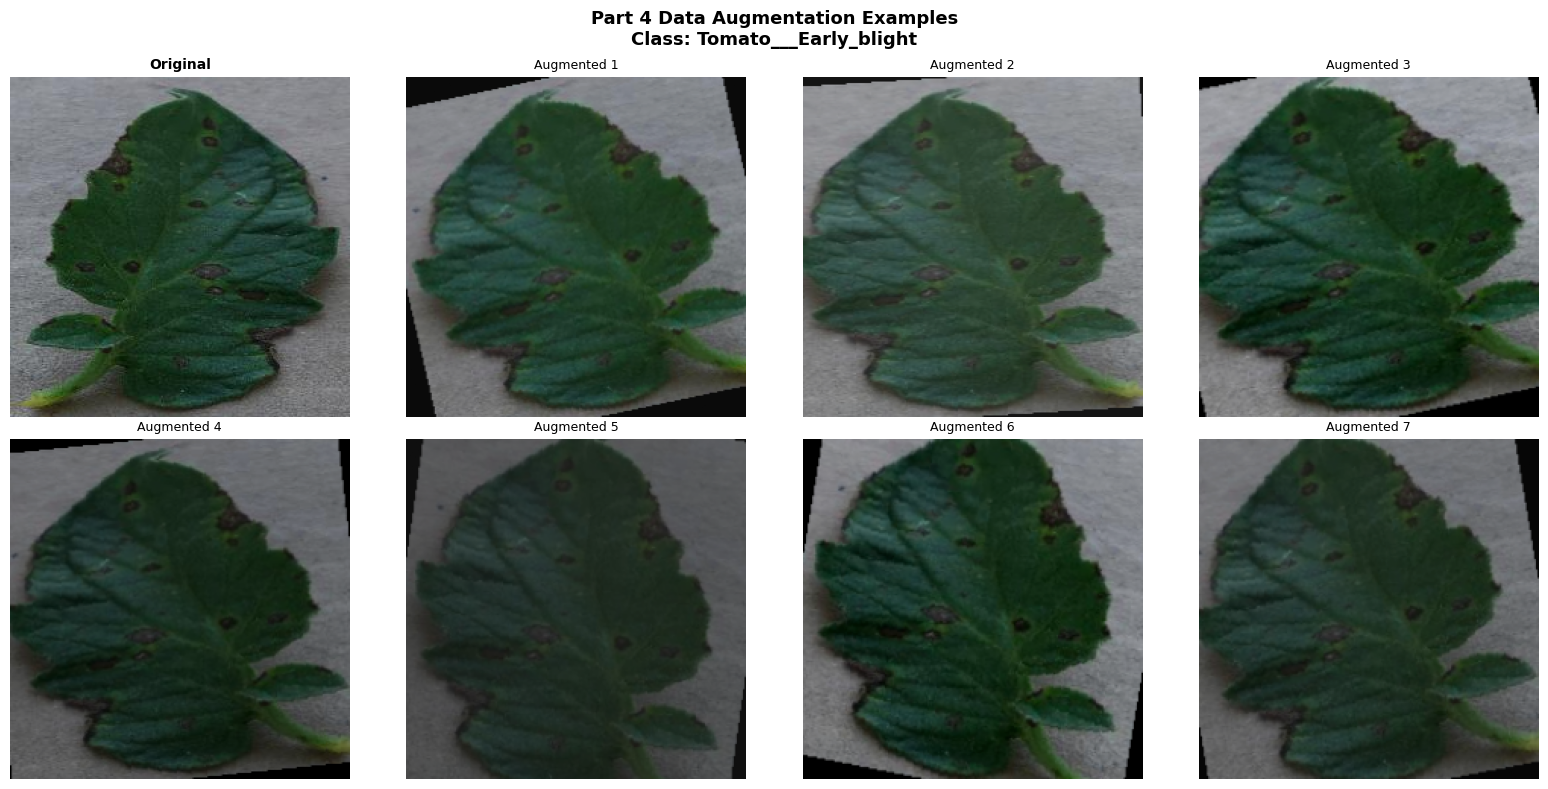

Saved: part4_augmentation_examples.png


In [4]:
# This transform is only for demonstration.
# It creates changed versions of the same image.
augmentation_demo = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
])

# Correct class name uses triple underscores.
sample_class = "Tomato___Early_blight"

sample_dir = os.path.join(TRAIN_DIR, sample_class)
sample_file = os.listdir(sample_dir)[0]
sample_path = os.path.join(sample_dir, sample_file)

original_img = Image.open(sample_path).convert("RGB")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f"Part 4 Data Augmentation Examples\nClass: {sample_class}", fontsize=13, fontweight="bold")

axes[0, 0].imshow(original_img)
axes[0, 0].set_title("Original", fontsize=10, fontweight="bold")
axes[0, 0].axis("off")

aug_names = [
    "Augmented 1",
    "Augmented 2",
    "Augmented 3",
    "Augmented 4",
    "Augmented 5",
    "Augmented 6",
    "Augmented 7"
]

for i, name in enumerate(aug_names):
    row, col = divmod(i + 1, 4)
    ax = axes[row, col]

    aug_tensor = augmentation_demo(original_img)
    aug_img = aug_tensor.permute(1, 2, 0).numpy()
    aug_img = np.clip(aug_img, 0, 1)

    ax.imshow(aug_img)
    ax.set_title(name, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("part4_augmentation_examples.png", dpi=150)
plt.show()

print("Saved: part4_augmentation_examples.png")

In [5]:
# Baseline transform: no augmentation.
baseline_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

# Augmented transform: random changes applied only to training images.
aug_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

# Validation images should NOT be augmented.
# Validation must stay consistent and fair.
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

print("Transforms ready.")

Transforms ready.


In [7]:
print("Loading datasets...")

# Training set without augmentation.
baseline_train = ImageFolder(root=TRAIN_DIR, transform=baseline_transform)

baseline_loader = DataLoader(
    baseline_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# Training set with augmentation.
aug_train = ImageFolder(root=TRAIN_DIR, transform=aug_transform)

aug_loader = DataLoader(
    aug_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# Same validation set for both experiments.
valid_dataset = ImageFolder(root=VALID_DIR, transform=val_transform)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=1,
    pin_memory=True
)

CLASS_NAMES = baseline_train.classes
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", NUM_CLASSES)
print("Training images:", len(baseline_train))
print("Validation images:", len(valid_dataset))
print("Baseline train batches:", len(baseline_loader))
print("Augmented train batches:", len(aug_loader))
print("Validation batches:", len(valid_loader))

Loading datasets...
Classes: 38
Training images: 70295
Validation images: 17572
Baseline train batches: 2197
Augmented train batches: 2197
Validation batches: 550


In [9]:
def build_model(num_classes, weights_path=None, device="cpu"):
    """
    Build ResNet18 with the correct final layer.
    Optionally load saved weights from Part 2.
    """

    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    if weights_path is not None and os.path.exists(weights_path):
        model.load_state_dict(torch.load(weights_path, map_location=device))
        print("Loaded weights from:", weights_path)
    else:
        print("No saved weights loaded. Starting from random weights.")

    return model.to(device)


def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Train the model for one full pass through the training dataset.
    """

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    """
    Evaluate the model on validation data.
    No training happens here.
    """

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            predicted = outputs.argmax(dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy

In [12]:
def run_experiment(name, train_loader, valid_loader, num_classes, num_epochs, device, weights_path=None):
    """
    Train one experiment and return training history.
    Example experiments:
    - Baseline without augmentation
    - Training with augmentation
    """

    print("\n" + "=" * 70)
    print("Experiment:", name)
    print("=" * 70)

    model = build_model(
        num_classes=num_classes,
        weights_path=weights_path,
        device=device
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=0.001)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.1,
        patience=2
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = 0.0

    for epoch in range(1, num_epochs + 1):
        print(f"\nEpoch {epoch}/{num_epochs}")

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc = evaluate(
            model,
            valid_loader,
            criterion,
            device
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Train | Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
        print(f"Val   | Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc

            safe_name = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
            model_path = f"resnet18_part4_{safe_name}_best.pth"

            torch.save(model.state_dict(), model_path)

            print(f"New best model saved: {model_path}")
            print(f"Best Val Acc: {best_val_acc:.2f}%")

    print("\nFinished experiment:", name)
    print(f"Best validation accuracy: {best_val_acc:.2f}%")

    return history, best_val_acc

In [13]:
history_baseline, best_baseline = run_experiment(
    name="Baseline No Aug",
    train_loader=baseline_loader,
    valid_loader=valid_loader,
    num_classes=NUM_CLASSES,
    num_epochs=NUM_EPOCHS,
    device=device,
    weights_path=BASE_MODEL_PATH
)


Experiment: Baseline No Aug
Loaded weights from: resnet18_plantdisease_part2_best.pth

Epoch 1/1
Train | Loss: 0.1226 | Acc: 96.02%
Val   | Loss: 0.0970 | Acc: 96.78%
New best model saved: resnet18_part4_baseline_no_aug_best.pth
Best Val Acc: 96.78%

Finished experiment: Baseline No Aug
Best validation accuracy: 96.78%


In [15]:
history_aug, best_aug = run_experiment(
    name="With Augmentation",
    train_loader=aug_loader,
    valid_loader=valid_loader,
    num_classes=NUM_CLASSES,
    num_epochs=NUM_EPOCHS,
    device=device,
    weights_path=BASE_MODEL_PATH
)


Experiment: With Augmentation
Loaded weights from: resnet18_plantdisease_part2_best.pth

Epoch 1/1
Train | Loss: 0.2163 | Acc: 92.98%
Val   | Loss: 0.1647 | Acc: 94.43%
New best model saved: resnet18_part4_with_augmentation_best.pth
Best Val Acc: 94.43%

Finished experiment: With Augmentation
Best validation accuracy: 94.43%


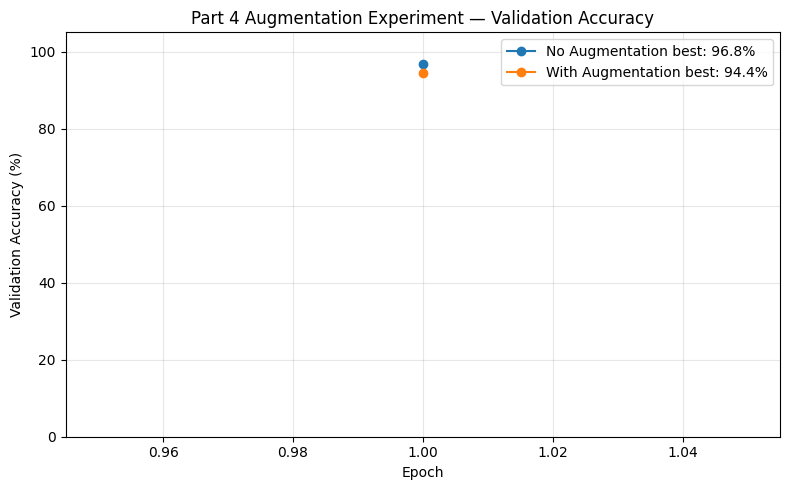

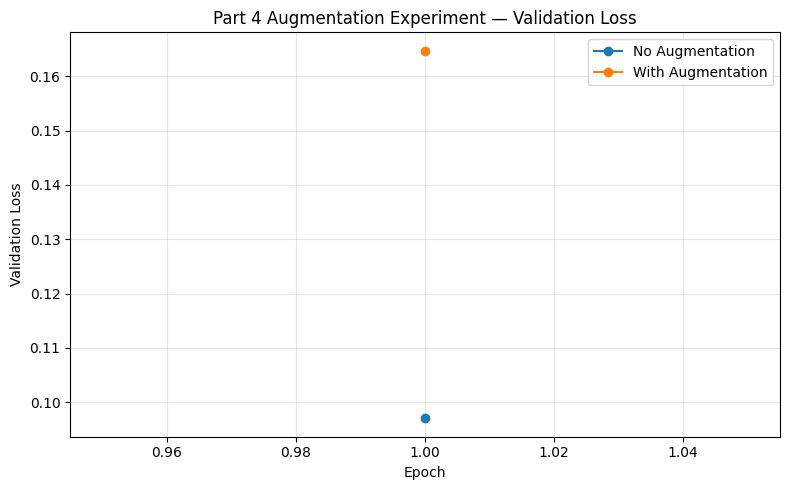

Saved:
part4_augmentation_accuracy.png
part4_augmentation_loss.png


In [16]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_baseline["val_acc"],
    marker="o",
    label=f"No Augmentation best: {best_baseline:.1f}%"
)

plt.plot(
    epochs,
    history_aug["val_acc"],
    marker="o",
    label=f"With Augmentation best: {best_aug:.1f}%"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Part 4 Augmentation Experiment — Validation Accuracy")
plt.ylim(0, 105)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("part4_augmentation_accuracy.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_baseline["val_loss"],
    marker="o",
    label="No Augmentation"
)

plt.plot(
    epochs,
    history_aug["val_loss"],
    marker="o",
    label="With Augmentation"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Part 4 Augmentation Experiment — Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("part4_augmentation_loss.png", dpi=150)
plt.show()

print("Saved:")
print("part4_augmentation_accuracy.png")
print("part4_augmentation_loss.png")

In [17]:
diff = best_aug - best_baseline

print("=" * 60)
print("Part 4 Experiment Summary")
print("=" * 60)

print(f"{'Metric':<35} {'No Aug':>12} {'With Aug':>12}")
print("-" * 60)

print(f"{'Best Val Accuracy':<35} {best_baseline:>11.2f}% {best_aug:>11.2f}%")

print(f"{'Final Epoch Val Acc':<35} "
      f"{history_baseline['val_acc'][-1]:>11.2f}% "
      f"{history_aug['val_acc'][-1]:>11.2f}%")

print(f"{'Improvement from Augmentation':<35} {diff:>+23.2f}%")

print("=" * 60)

if diff > 0:
    print(f"Augmentation improved validation accuracy by {diff:.2f}%.")
elif diff == 0:
    print("Augmentation gave the same best validation accuracy.")
else:
    print(f"Augmentation reduced validation accuracy by {diff:.2f}%.")
    print("That can happen if augmentation is too strong or if more epochs are needed.")

Part 4 Experiment Summary
Metric                                    No Aug     With Aug
------------------------------------------------------------
Best Val Accuracy                         96.78%       94.43%
Final Epoch Val Acc                       96.78%       94.43%
Improvement from Augmentation                         -2.35%
Augmentation reduced validation accuracy by -2.35%.
That can happen if augmentation is too strong or if more epochs are needed.


In [18]:
print("Overfitting Check")
print("=" * 60)

for name, history in [
    ("No Augmentation", history_baseline),
    ("With Augmentation", history_aug)
]:
    train_final = history["train_acc"][-1]
    val_final = history["val_acc"][-1]
    gap = train_final - val_final

    print("\n", name)
    print("Train Acc final:", f"{train_final:.2f}%")
    print("Val Acc final:  ", f"{val_final:.2f}%")
    print("Gap:            ", f"{gap:.2f}%")

    if gap > 10:
        print("Possible overfitting: training accuracy is much higher than validation accuracy.")
    else:
        print("Gap looks reasonable.")

Overfitting Check

 No Augmentation
Train Acc final: 96.02%
Val Acc final:   96.78%
Gap:             -0.76%
Gap looks reasonable.

 With Augmentation
Train Acc final: 92.98%
Val Acc final:   94.43%
Gap:             -1.44%
Gap looks reasonable.


In [19]:
files_to_check = [
    "part4_augmentation_examples.png",
    "part4_augmentation_accuracy.png",
    "part4_augmentation_loss.png",
    "resnet18_part4_baseline_no_aug_best.pth",
    "resnet18_part4_with_augmentation_best.pth"
]

for f in files_to_check:
    print(f, "exists:", os.path.exists(f))

part4_augmentation_examples.png exists: True
part4_augmentation_accuracy.png exists: True
part4_augmentation_loss.png exists: True
resnet18_part4_baseline_no_aug_best.pth exists: True
resnet18_part4_with_augmentation_best.pth exists: True
